# AML Alert Prioritization & Case Management System

In [226]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [227]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/subhasishchoudhury26/aml-alert-prioritization-data/AML_Final_Dashboard_Data.csv


In [228]:
df = pd.read_csv(
    '/kaggle/input/datasets/subhasishchoudhury26/aml-alert-prioritization-data/AML_Final_Dashboard_Data.csv'
)

print("Shape:", df.shape)

df.head()

Shape: (50000, 16)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,Risk_Score,Risk_Level,Risk_Score_V2,Risk_Level_V2,Suspicious_Alert
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0,Low,0,Low,False
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0,Low,0,Low,False
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,30,Medium,50,Medium,True
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,20,Low,40,Medium,True
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0,Low,0,Low,False


In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   step              50000 non-null  int64  
 1   type              50000 non-null  object 
 2   amount            50000 non-null  float64
 3   nameOrig          50000 non-null  object 
 4   oldbalanceOrg     50000 non-null  float64
 5   newbalanceOrig    50000 non-null  float64
 6   nameDest          50000 non-null  object 
 7   oldbalanceDest    50000 non-null  float64
 8   newbalanceDest    50000 non-null  float64
 9   isFraud           50000 non-null  int64  
 10  isFlaggedFraud    50000 non-null  int64  
 11  Risk_Score        50000 non-null  int64  
 12  Risk_Level        50000 non-null  object 
 13  Risk_Score_V2     50000 non-null  int64  
 14  Risk_Level_V2     50000 non-null  object 
 15  Suspicious_Alert  50000 non-null  bool   
dtypes: bool(1), float64(5), int64(5), object

In [230]:
alerts_df = df[df['Suspicious_Alert'] == True].copy()

print("Total Transactions:", len(df))
print("Total Alerts:", len(alerts_df))

Total Transactions: 50000
Total Alerts: 20276


In [231]:
import matplotlib.pyplot as plt

# Exploratory Data Analysis (EDA)

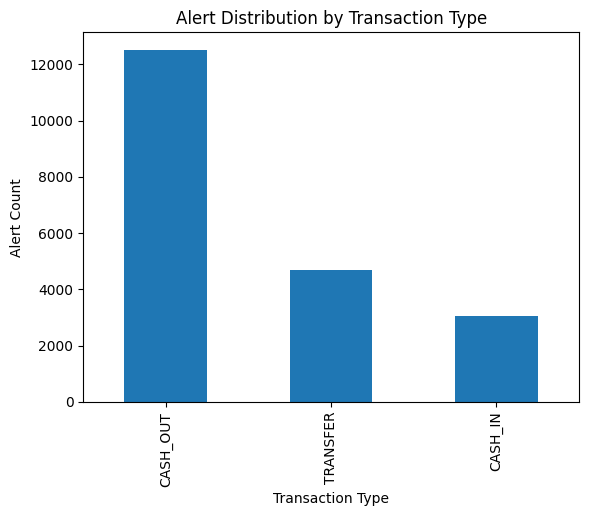

In [232]:
alerts_df['type'].value_counts().plot(
    kind='bar'
)

plt.title('Alert Distribution by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Alert Count')

plt.show()

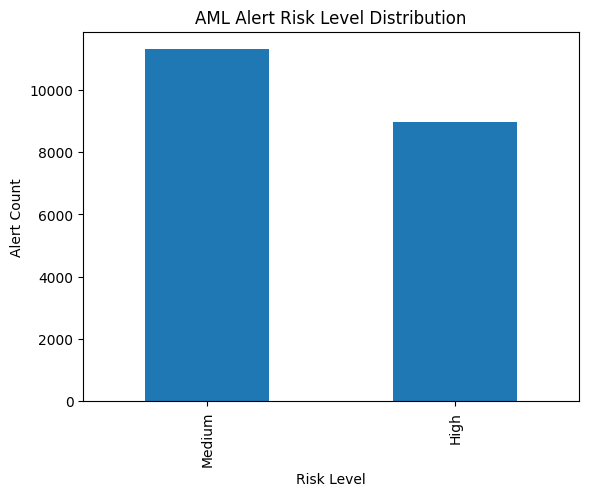

In [233]:
alerts_df['Risk_Level_V2'].value_counts().plot(
    kind='bar'
)

plt.title('AML Alert Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Alert Count')

plt.show()

In [234]:
print("Total Alerts:", len(alerts_df))

print("High Risk Alerts:",
      (alerts_df['Risk_Level_V2'] == 'High').sum())

print("Fraud Alerts:",
      alerts_df['isFraud'].sum())

print("Average Risk Score:",
      round(alerts_df['Risk_Score_V2'].mean(),2))

Total Alerts: 20276
High Risk Alerts: 8968
Fraud Alerts: 100
Average Risk Score: 63.56


In [235]:
alerts_df['Alert_ID'] = [
    f'ALT{i:05d}'
    for i in range(1, len(alerts_df) + 1)
]

alerts_df[['Alert_ID']].head()

,Alert_ID
2,ALT00001
3,ALT00002
15,ALT00003
19,ALT00004
24,ALT00005


In [236]:
def assign_priority(score):

    if score >= 100:
        return "Critical"

    elif score >= 70:
        return "High"

    elif score >= 40:
        return "Medium"

    else:
        return "Low"

In [237]:
alerts_df['Priority'] = alerts_df['Risk_Score_V2'].apply(assign_priority)

alerts_df[['Risk_Score_V2', 'Priority']].head()

,Risk_Score_V2,Priority
2,50,Medium
3,40,Medium
15,80,High
19,90,High
24,90,High


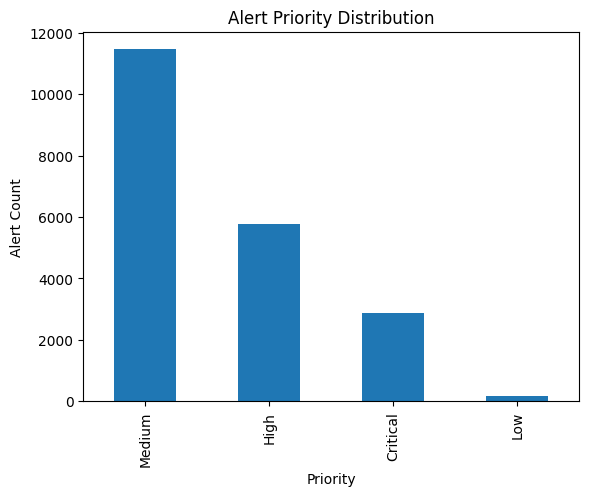

In [238]:
alerts_df['Priority'].value_counts().plot(
    kind='bar'
)

plt.title('Alert Priority Distribution')
plt.xlabel('Priority')
plt.ylabel('Alert Count')

plt.show()

In [239]:
alerts_df['Case_ID'] = [
    f'CASE{i:05d}'
    for i in range(1, len(alerts_df) + 1)
]

alerts_df[['Alert_ID', 'Case_ID']].head()

,Alert_ID,Case_ID
2,ALT00001,CASE00001
3,ALT00002,CASE00002
15,ALT00003,CASE00003
19,ALT00004,CASE00004
24,ALT00005,CASE00005


In [240]:
import numpy as np

analysts = [
    'Analyst_A',
    'Analyst_B',
    'Analyst_C',
    'Analyst_D'
]

alerts_df['Investigator'] = np.random.choice(
    analysts,
    size=len(alerts_df)
)

alerts_df[['Case_ID', 'Investigator']].head()

,Case_ID,Investigator
2,CASE00001,Analyst_C
3,CASE00002,Analyst_B
15,CASE00003,Analyst_A
19,CASE00004,Analyst_A
24,CASE00005,Analyst_A


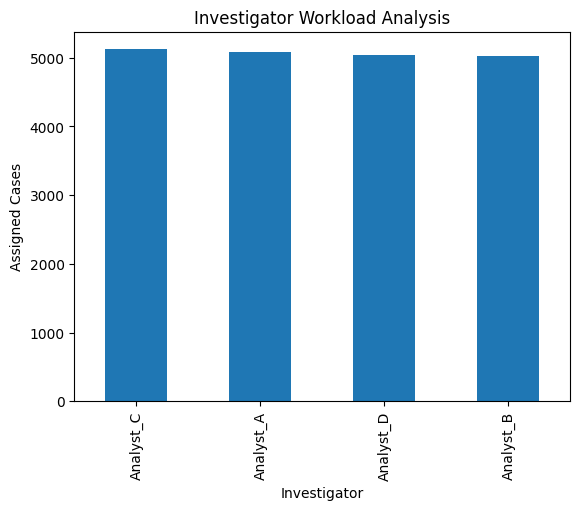

In [241]:
alerts_df['Investigator'].value_counts().plot(
    kind='bar'
)

plt.title('Investigator Workload Analysis')
plt.xlabel('Investigator')
plt.ylabel('Assigned Cases')

plt.show()

In [242]:
# Set random seed for reproducibility
np.random.seed(55)

statuses = [
    'Open',
    'Under Review',
    'Escalated',
    'Closed'
]

probabilities = [
    0.35,   # Open
    0.35,   # Under Review
    0.10,   # Escalated
    0.20    # Closed
]

alerts_df['Case_Status'] = np.random.choice(
    statuses,
    size=len(alerts_df),
    p=probabilities
)

alerts_df[['Case_ID', 'Case_Status']].head()

,Case_ID,Case_Status
2,CASE00001,Open
3,CASE00002,Closed
15,CASE00003,Under Review
19,CASE00004,Open
24,CASE00005,Under Review


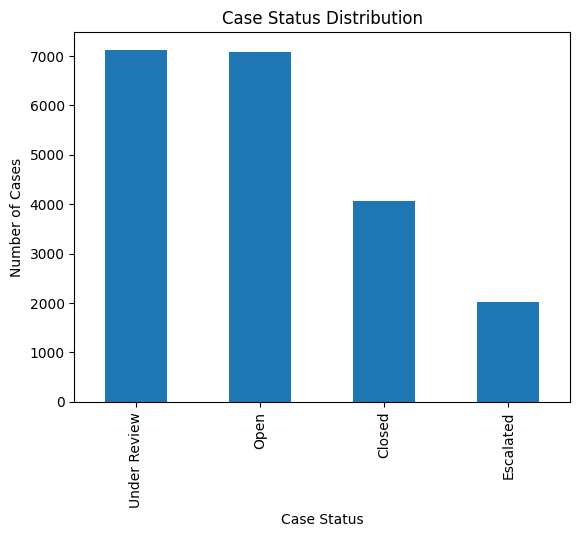

In [243]:
alerts_df['Case_Status'].value_counts().plot(
    kind='bar'
)

plt.title('Case Status Distribution')
plt.xlabel('Case Status')
plt.ylabel('Number of Cases')

plt.show()

In [244]:
def sar_decision(priority):

    if priority == 'Critical':
        return 'SAR Required'

    elif priority == 'High':
        return 'SAR Review Needed'

    else:
        return 'No SAR Required'


alerts_df['SAR_Decision'] = alerts_df['Priority'].apply(
    sar_decision
)

alerts_df[
    ['Case_ID', 'Priority', 'SAR_Decision']
].head()

,Case_ID,Priority,SAR_Decision
2,CASE00001,Medium,No SAR Required
3,CASE00002,Medium,No SAR Required
15,CASE00003,High,SAR Review Needed
19,CASE00004,High,SAR Review Needed
24,CASE00005,High,SAR Review Needed


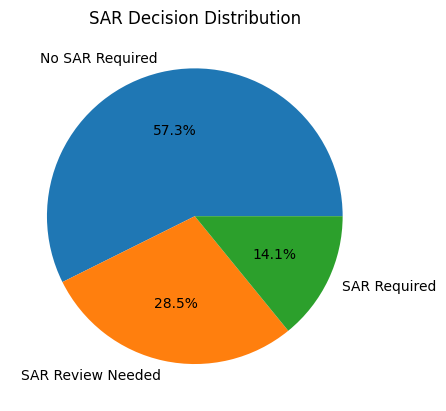

In [245]:
alerts_df['SAR_Decision'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('SAR Decision Distribution')
plt.ylabel('')

plt.show()

In [246]:
alerts_df[
    alerts_df['Priority'] == 'Critical'
].sort_values(
    by='amount',
    ascending=False
)[[
    'Case_ID',
    'amount',
    'Risk_Score_V2',
    'Investigator',
    'Case_Status',
    'SAR_Decision'
]].head(10)

,Case_ID,amount,Risk_Score_V2,Investigator,Case_Status,SAR_Decision
4441,CASE01191,10000000.00,110,Analyst_C,Closed,SAR Required
4440,CASE01190,10000000.00,100,Analyst_A,Open,SAR Required
16720,CASE05040,5677662.29,120,Analyst_A,Open,SAR Required
10396,CASE02892,5460002.91,110,Analyst_B,Open,SAR Required
10395,CASE02891,5460002.91,120,Analyst_B,Under Review,SAR Required
46199,CASE18378,4764218.76,120,Analyst_C,Open,SAR Required
44942,CASE17753,4626419.46,120,Analyst_C,Closed,SAR Required
49554,CASE20037,4203370.00,120,Analyst_A,Closed,SAR Required
42340,CASE16331,4201421.61,120,Analyst_B,Open,SAR Required
28375,CASE10004,4199621.54,120,Analyst_A,Under Review,SAR Required


In [247]:
summary = pd.DataFrame({
    'Metric': [
        'Total Alerts',
        'Critical Alerts',
        'High Priority Alerts',
        'Cases Requiring SAR',
        'Cases Requiring SAR Review',
        'No SAR Required Cases',
        'Open Cases',
        'Under Review Cases',
        'Closed Cases',
        'Escalated Cases'
    ],
    'Value': [
        len(alerts_df),
        (alerts_df['Priority'] == 'Critical').sum(),
        (alerts_df['Priority'] == 'High').sum(),
        (alerts_df['SAR_Decision'] == 'SAR Required').sum(),
        (alerts_df['SAR_Decision'] == 'SAR Review Needed').sum(),
        (alerts_df['SAR_Decision'] == 'No SAR Required').sum(),
        (alerts_df['Case_Status'] == 'Open').sum(),
        (alerts_df['Case_Status'] == 'Under Review').sum(),
        (alerts_df['Case_Status'] == 'Closed').sum(),
        (alerts_df['Case_Status'] == 'Escalated').sum()
    ]
})

summary

,Metric,Value
0,Total Alerts,20276
1,Critical Alerts,2861
2,High Priority Alerts,5787
3,Cases Requiring SAR,2861
4,Cases Requiring SAR Review,5787
5,No SAR Required Cases,11628
6,Open Cases,7083
7,Under Review Cases,7124
8,Closed Cases,4055
9,Escalated Cases,2014


In [248]:
alerts_df.to_csv(
    'AML_Case_Management_Final.csv',
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


# Project Conclusion

This project successfully developed an AML Alert Prioritization & Case Management System using Python and Pandas.

Key outcomes:

1. Extracted suspicious alerts from AML monitoring data.
2. Prioritized alerts using a risk-based approach.
3. Generated investigation cases and assigned analysts.
4. Tracked case status throughout the investigation process.
5. Implemented a SAR Decision Engine.
6. Produced management-ready AML metrics and insights.
7. Produced management-ready AML metrics and operational insights.


Business Impact:

The system helps AML teams prioritize high-risk alerts, distribute investigation workload efficiently, monitor case progress, and identify cases requiring SAR consideration.


 
 
 